# Deep Neural Learning Modeling (Regression)

This notebook builds and evaluates deep neural network models (MLP and 1D CNN) for Walmart weekly sales forecasting. It includes: data preparation, model training with early stopping, hyperparameter tables, results tables, and diagnostic figures.

## 2. Data Preprocessing

This section describes the comprehensive data preprocessing pipeline applied to the Walmart sales dataset to prepare it for deep neural network training.

---

### 2.1 Data Cleaning

**Initial Data Quality Assessment:**
- **Dataset:** Walmart weekly sales data for 45 stores (walmart-sales-dataset-of-45stores.csv)
- **Target Variable:** Weekly_Sales (continuous, positive values)
- **Temporal Coverage:** Multiple years of weekly observations
- **Missing Values:** Present in various features due to data collection gaps

**Cleaning Steps:**

1. **Target Variable Filtering:**
   ```python
   df = df.dropna(subset=['Weekly_Sales'])
   ```
   - Removed all observations where Weekly_Sales is missing
   - Rationale: Cannot train supervised model without target labels

2. **Date Parsing:**
   ```python
   df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
   ```
   - Convert date strings to datetime objects
   - `errors='coerce'` converts invalid dates to NaT (Not-a-Time)
   - Preserves rows with temporal information for chronological splitting

3. **Missing Value Handling Strategy:**
   - **Approach:** Defer imputation until after train/test split
   - **Rationale:** Prevent data leakage (test set statistics should not influence training)
   - **Method:** Median imputation fitted on training set only

---

### 2.2 Feature Engineering

**Philosophy:** Transform raw data into informative representations that capture temporal patterns, trends, and economic context.

**2.2.1 Temporal Features (11 features)**

**Basic Temporal Components:**
```python
df['Month'] = df['Date'].dt.month          # 1-12
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Week'] = df['Date'].dt.isocalendar().week  # 1-52
df['Quarter'] = df['Date'].dt.quarter      # 1-4
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype('Int64')  # Binary flag
```

**Cyclical Encodings** (to capture periodic nature):
- **Problem:** Month 12 and Month 1 are adjacent in time but distant numerically
- **Solution:** Sine/cosine encoding preserves circular relationships

```python
# Month encoding (12 months per year)
df['Month_sin'] = np.sin(2 * π * (Month - 1) / 12)
df['Month_cos'] = np.cos(2 * π * (Month - 1) / 12)

# Week encoding (52 weeks per year)
df['Week_sin'] = np.sin(2 * π * (Week - 1) / 52)
df['Week_cos'] = np.cos(2 * π * (Week - 1) / 52)

# Day of week encoding (7 days per week)
df['DoW_sin'] = np.sin(2 * π * DayOfWeek / 7)
df['DoW_cos'] = np.cos(2 * π * DayOfWeek / 7)
```

**Mathematical Rationale:**
- For a value $x$ in range [0, n), encode as:
  - $\text{sin\_enc} = \sin(2\pi x / n)$
  - $\text{cos\_enc} = \cos(2\pi x / n)$
- Euclidean distance between encodings reflects true temporal proximity
- Example: December (12) and January (1) are close in encoded space

**2.2.2 Lag Features (5 features)**

Capture autoregressive patterns by including past sales values:

```python
# Group by Store to maintain store-specific histories
df['Sales_Lag1'] = df.groupby('Store')['Weekly_Sales'].shift(1)   # Previous week
df['Sales_Lag2'] = df.groupby('Store')['Weekly_Sales'].shift(2)   # 2 weeks ago
df['Sales_Lag4'] = df.groupby('Store')['Weekly_Sales'].shift(4)   # 4 weeks ago
df['Sales_Lag8'] = df.groupby('Store')['Weekly_Sales'].shift(8)   # 8 weeks ago
df['Sales_Lag12'] = df.groupby('Store')['Weekly_Sales'].shift(12) # 12 weeks ago (quarterly)
```

**Design Rationale:**
- **Lag 1-2:** Capture immediate short-term trends
- **Lag 4:** Monthly patterns (assuming ~4 weeks/month)
- **Lag 8:** Bi-monthly patterns
- **Lag 12:** Quarterly seasonality
- **Store Grouping:** Each store has independent sales trajectory

**2.2.3 Rolling Statistics (4 features)**

Aggregate recent history to capture trends and volatility:

```python
# 4-week rolling window (short-term)
df['Sales_Rolling_Mean_4'] = df.groupby('Store')['Weekly_Sales']
                                .transform(lambda x: x.rolling(4, min_periods=1).mean())
df['Sales_Rolling_Std_4'] = df.groupby('Store')['Weekly_Sales']
                               .transform(lambda x: x.rolling(4, min_periods=1).std())

# 12-week rolling window (long-term)
df['Sales_Rolling_Mean_12'] = df.groupby('Store')['Weekly_Sales']
                                 .transform(lambda x: x.rolling(12, min_periods=1).mean())
df['Sales_Rolling_Std_12'] = df.groupby('Store')['Weekly_Sales']
                                .transform(lambda x: x.rolling(12, min_periods=1).std())
```

**Interpretation:**
- **Mean:** Average sales level over recent period (trend indicator)
- **Std:** Sales volatility (uncertainty indicator)
- **4-week window:** Recent momentum
- **12-week window:** Longer-term baseline

**2.2.4 Interaction Features (3 features)**

Capture synergistic effects between variables:

```python
df['Temp_Unemployment'] = df['Temperature'] * df['Unemployment']
df['Holiday_CPI'] = df['Holiday_Flag'] * df['CPI']
df['Store_Encoded'] = df['Store']  # Store identifier as numeric feature
```

**Rationale:**
- **Temperature × Unemployment:** Economic downturn may amplify weather effects on shopping
- **Holiday × CPI:** Inflation impact may be different during holidays
- **Store ID:** Captures store-specific baseline effects

**2.2.5 Feature Summary**

| Category | Count | Examples | Purpose |
|----------|-------|----------|---------|
| Temporal | 11 | Month, Week_sin, IsWeekend | Seasonality, periodicity |
| Environmental/Economic | 4 | Temperature, CPI, Unemployment | External factors |
| Lag Features | 5 | Sales_Lag1, Sales_Lag8 | Autoregressive patterns |
| Rolling Statistics | 4 | Rolling_Mean_4, Rolling_Std_12 | Trend, volatility |
| Interactions | 3 | Temp_Unemployment, Store_Encoded | Synergies, store effects |
| Binary Indicator | 1 | Holiday_Flag | Special events |
| **Total** | **28** | | **Final feature space** |

---

### 2.3 Data Normalization

**2.3.1 Feature Standardization (Z-Score Normalization)**

Applied to all 28 input features:

$$x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

Where:
- $x_{ij}$: Original value of feature $j$ for sample $i$
- $\mu_j$: Mean of feature $j$ computed on **training set only**
- $\sigma_j$: Standard deviation of feature $j$ computed on **training set only**
- $x'_{ij}$: Standardized value

**Implementation:**
```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit on training set
X_val = scaler.transform(X_val)          # Apply to validation set
X_test = scaler.transform(X_test)        # Apply to test set
```

**Rationale:**
1. **Scale Alignment:** Features have vastly different ranges (Temperature: 0-100°F, CPI: 100-250, Sales: 0-3M)
2. **Gradient Stability:** Prevents features with large magnitudes from dominating gradients
3. **Activation Function Efficiency:** Centers data around zero, ideal for ReLU/sigmoid activations
4. **Prevents Data Leakage:** Scaling parameters computed only from training data

**Post-Standardization Statistics:**
- Training set: Mean ≈ 0, Std ≈ 1 (by construction)
- Validation/Test sets: Mean ≈ 0, Std ≈ 1 (approximately, not exact)

**2.3.2 Target Variable Transformation**

Applied log transformation to handle right-skewed sales distribution:

$$y' = \log(1 + y)$$

**Before Transformation:**
- Distribution: Heavily right-skewed (long tail of high-sales weeks)
- Range: $275,142 to $3,766,687
- Mean: ~$1.1M, Std: ~$492K

**After Transformation:**
- Distribution: Approximately normal (more symmetric)
- Reduces influence of extreme outliers
- Stabilizes variance across different sales levels

**Inverse Transformation (for predictions):**
$$\hat{y} = \exp(\hat{y}') - 1$$

Applied after model prediction to return to original sales scale for evaluation.

---

### 2.4 Data Splitting Strategy

**2.4.1 Chronological Split (60% / 20% / 20%)**

**Methodology:**
```python
# Sort by date to preserve temporal ordering
order = np.argsort(df['Date'].values)
X_ordered = X.iloc[order]
y_ordered = y.iloc[order]

# Split chronologically
n_train = int(n * 0.6)
n_val = int(n * 0.2)

X_train, y_train = X_ordered[:n_train], y_ordered[:n_train]
X_val, y_val = X_ordered[n_train:n_train+n_val], y_ordered[n_train:n_train+n_val]
X_test, y_test = X_ordered[n_train+n_val:], y_ordered[n_train+n_val:]
```

**Rationale:**
1. **Temporal Integrity:** Training always precedes validation, which precedes test
2. **Realistic Evaluation:** Models predict future sales using only past data
3. **Prevents Look-Ahead Bias:** No information leakage from future to past
4. **Time-Series Best Practice:** Random splits would violate temporal causality

**Split Sizes:**
- **Training:** 60% of data (earliest observations)
- **Validation:** 20% of data (middle period) - used for early stopping, hyperparameter tuning
- **Test:** 20% of data (most recent observations) - held-out for final evaluation

**2.4.2 Missing Value Imputation (Post-Split)**

Applied **after** splitting to prevent data leakage:

```python
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)  # Learn medians from training set
X_val = imputer.transform(X_val)          # Apply training medians
X_test = imputer.transform(X_test)        # Apply training medians
```

**Strategy:** Median imputation
- **Robust to Outliers:** Median less sensitive than mean to extreme values
- **Handles Missing Lags:** Early observations lack lag features (no prior history)
- **Store-Specific:** When grouped by store, respects store-level patterns

**Missing Value Sources:**
- First observation per store: Cannot compute Lag1, Lag2, etc.
- First 4 weeks per store: Cannot compute Rolling_Mean_4
- First 12 weeks per store: Cannot compute Rolling_Mean_12
- Invalid dates: Result in NaT, propagate to derived temporal features

---

### 2.5 Data Augmentation

**Note:** Traditional augmentation techniques (rotation, flipping, noise injection) are not applied to tabular data as they would distort semantic meaning.

**Instead, Implicit Augmentation via:**
1. **Dropout (p=0.15-0.3):** Randomly drops neurons during training, effectively creating different sub-networks each epoch
2. **Batch Sampling:** Random mini-batch selection (size 32-64) exposes different data subsets each iteration
3. **Feature Engineering:** Cyclical encodings, lags, and rolling stats create diverse representations of same underlying patterns

---

### 2.6 Dimensionality Reduction

**Approach:** None applied

**Rationale:**
1. **Modest Feature Count:** 28 features is manageable for modern DNNs (no curse of dimensionality)
2. **All Features Informative:** Each engineered feature captures distinct aspect (temporal, economic, historical)
3. **Neural Network Performs Implicit Reduction:** Hidden layers (256→128→64) progressively learn compressed representations
4. **Interpretability:** Keeping original features aids in understanding model behavior

**Alternative Considered (Not Used):**
- **PCA:** Would lose interpretability; linear combinations of cyclical encodings and lags lack semantic meaning
- **Feature Selection:** Risk discarding useful interactions; neural networks can learn to ignore irrelevant features via weight decay

---

### 2.7 Final Preprocessed Data Characteristics

**Training Set:**
- Shape: (n_train, 28) - 60% of total observations
- Features: Standardized (mean ≈ 0, std ≈ 1)
- Target: Log-transformed (y' = log(1 + y))
- Missing Values: Imputed with training set medians
- Temporal Order: Earliest observations in dataset

**Validation Set:**
- Shape: (n_val, 28) - 20% of total observations
- Features: Standardized using training set parameters
- Target: Log-transformed
- Missing Values: Imputed with training set medians
- Temporal Order: Middle period observations

**Test Set:**
- Shape: (n_test, 28) - 20% of total observations
- Features: Standardized using training set parameters
- Target: Log-transformed
- Missing Values: Imputed with training set medians
- Temporal Order: Most recent observations (future relative to training)

**Data Quality Assurance:**
- ✓ No missing values after imputation
- ✓ All features on comparable scales (standardized)
- ✓ Target distribution normalized (log-transformed)
- ✓ Temporal causality preserved (chronological split)
- ✓ No data leakage (all preprocessing fitted on training set only)

---

### 2.8 Preprocessing Pipeline Summary

```
Raw Data (Walmart Sales CSV)
         ↓
[1] Load & Parse Dates
         ↓
[2] Feature Engineering
    • Temporal features (11)
    • Lag features (5)
    • Rolling statistics (4)
    • Interactions (3)
    • Economic features (4)
    • Indicator (1)
         ↓
[3] Chronological Split (60/20/20)
    • Training set (earliest)
    • Validation set (middle)
    • Test set (latest)
         ↓
[4] Missing Value Imputation
    • Fit on training set
    • Apply to val/test sets
         ↓
[5] Feature Standardization
    • Fit on training set
    • Apply to val/test sets
         ↓
[6] Target Transformation
    • log(1 + y) for all sets
         ↓
Final Preprocessed Data
    • X_train, X_val, X_test: (n, 28) standardized
    • y_train, y_val, y_test: log-transformed
```

This preprocessing pipeline ensures high-quality, properly scaled data that respects temporal causality and prevents data leakage, providing a robust foundation for deep neural network training.

## 3. Model Architecture and Design

This section describes the three deep neural network architectures evaluated for weekly sales forecasting: Multi-Layer Perceptron (MLP), Convolutional Neural Network (CNN), and Long Short-Term Memory (LSTM) network.

---

### 3.1 Input Feature Space

All models operate on a standardized 28-dimensional feature space constructed through comprehensive feature engineering:

**Feature Categories:**
- **Temporal Features (11):** Month, DayOfWeek, Week, Quarter, IsWeekend, plus cyclical encodings (Month_sin, Month_cos, Week_sin, Week_cos, DoW_sin, DoW_cos)
- **Environmental/Economic Features (4):** Temperature, Fuel_Price, CPI, Unemployment
- **Lag Features (5):** Sales_Lag1, Sales_Lag2, Sales_Lag4, Sales_Lag8, Sales_Lag12
- **Rolling Statistics (4):** Sales_Rolling_Mean_4, Sales_Rolling_Std_4, Sales_Rolling_Mean_12, Sales_Rolling_Std_12
- **Interaction Features (3):** Temp_Unemployment, Holiday_CPI, Store_Encoded
- **Binary Indicator (1):** Holiday_Flag

**Preprocessing Pipeline:**
1. Missing value imputation using median strategy (fitted on training set only)
2. Standardization via z-score normalization: $x' = \frac{x - \mu}{\sigma}$ (fitted on training set only)
3. Target transformation: $y' = \log(1 + y)$ to handle right-skewed sales distribution
4. Chronological train/validation/test split (60%/20%/20%) to preserve temporal ordering

---

### 3.2 Multi-Layer Perceptron (MLP) Architecture

**Design Philosophy:** Fully-connected feedforward network treating each input feature independently, learning arbitrary non-linear feature combinations through stacked dense layers.

**Architecture Specification:**

```
Input Layer:    28 features (standardized)
                ↓
Hidden Layer 1: 256 neurons, ReLU activation
                → Dropout (p=0.15)
                → Batch Normalization
                ↓
Hidden Layer 2: 128 neurons, ReLU activation
                → Dropout (p=0.15)
                → Batch Normalization
                ↓
Hidden Layer 3: 64 neurons, ReLU activation
                → Dropout (p=0.15)
                → Batch Normalization
                ↓
Output Layer:   1 neuron, Linear activation (regression target)
```

**Mathematical Formulation:**

For layer $\ell$ with input $h^{(\ell-1)}$:

$$h^{(\ell)} = \text{BN}(\text{Dropout}(\text{ReLU}(W^{(\ell)} h^{(\ell-1)} + b^{(\ell)})))$$

Where:
- $W^{(\ell)} \in \mathbb{R}^{n_{\ell} \times n_{\ell-1}}$ is the weight matrix
- $b^{(\ell)} \in \mathbb{R}^{n_{\ell}}$ is the bias vector
- ReLU$(x) = \max(0, x)$ is the activation function
- Dropout randomly zeros elements with probability $p=0.15$ during training
- BN normalizes activations: $\hat{h} = \gamma \frac{h - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$

**Parameter Count:**
- Layer 1: $28 \times 256 + 256 = 7,424$ parameters
- Layer 2: $256 \times 128 + 128 = 32,896$ parameters
- Layer 3: $128 \times 64 + 64 = 8,256$ parameters
- Output: $64 \times 1 + 1 = 65$ parameters
- **Total (excluding BN):** ~48,641 trainable parameters

**Design Rationale:**
- **Decreasing width (256→128→64):** Progressive dimensionality reduction forces hierarchical feature abstraction
- **Moderate dropout (0.15):** Prevents co-adaptation without excessive regularization
- **Batch normalization:** Stabilizes training by reducing internal covariate shift
- **ReLU activation:** Computationally efficient, mitigates vanishing gradients

---

### 3.3 Convolutional Neural Network (CNN) Architecture

**Design Philosophy:** Apply 1D convolutions to detect local patterns across feature dimensions, treating the 28-dimensional feature vector as a spatial sequence.

**Architecture Specification:**

```
Input Layer:      28 features (standardized)
                  ↓
Reshape Layer:    (28, 1) - treat features as 1D sequence
                  ↓
Conv1D Layer 1:   64 filters, kernel size 3, ReLU, same padding
                  → Batch Normalization
                  ↓
Conv1D Layer 2:   64 filters, kernel size 3, ReLU, same padding
                  → Batch Normalization
                  ↓
Flatten Layer:    28 × 64 = 1,792 features
                  ↓
Dense Layer 1:    128 neurons, ReLU activation
                  → Batch Normalization
                  → Dropout (p=0.2)
                  ↓
Dense Layer 2:    64 neurons, ReLU activation
                  → Batch Normalization
                  → Dropout (p=0.2)
                  ↓
Output Layer:     1 neuron, Linear activation
```

**Mathematical Formulation:**

For 1D convolution with filter $w \in \mathbb{R}^{k}$ and input $x \in \mathbb{R}^{n}$:

$$(x * w)[i] = \sum_{j=0}^{k-1} x[i+j] \cdot w[j]$$

With $k=3$ (kernel size) and 64 filters, each convolutional layer learns 64 different local patterns.

**Parameter Count:**
- Conv1D Layer 1: $(3 \times 1 \times 64) + 64 = 256$ parameters
- Conv1D Layer 2: $(3 \times 64 \times 64) + 64 = 12,352$ parameters
- Dense Layer 1: $(1792 \times 128) + 128 = 229,504$ parameters
- Dense Layer 2: $(128 \times 64) + 64 = 8,256$ parameters
- Output: $64 \times 1 + 1 = 65$ parameters
- **Total (excluding BN):** ~250,433 trainable parameters

**Design Rationale:**
- **1D convolution:** Scans a sliding window (size 3) across feature dimension to detect local co-occurrence patterns
- **Same padding:** Preserves spatial dimension (28 features remain 28 after convolution)
- **Stacked convolutions:** Two layers allow learning hierarchical feature representations
- **Flatten + Dense:** Aggregates convolutional features into global representation

**Critical Assumption:** Adjacent features in the input vector share semantic relationships (spatial locality). This assumption is **violated** in tabular data where feature ordering is arbitrary.

---

### 3.4 Long Short-Term Memory (LSTM) Architecture

**Design Philosophy:** Process temporal sequences using recurrent connections, capturing long-term dependencies across multiple time steps via gating mechanisms.

**Architecture Specification:**

```
Input Layer:      (8, 28) - 8-week sliding window, 28 features per timestep
                  ↓
LSTM Layer 1:     128 units, return_sequences=True
                  → Batch Normalization
                  → Dropout (p=0.3)
                  ↓
LSTM Layer 2:     64 units, return_sequences=False
                  → Batch Normalization
                  → Dropout (p=0.3)
                  ↓
Dense Layer 1:    64 neurons, ReLU activation
                  → Batch Normalization
                  → Dropout (p=0.3)
                  ↓
Output Layer:     1 neuron, Linear activation
```

**Mathematical Formulation:**

LSTM cell processes input $x_t$ and previous hidden state $h_{t-1}$ through three gates:

$$
\begin{align}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(Forget gate)} \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(Input gate)} \\
\tilde{C}_t &= \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) \quad \text{(Candidate memory)} \\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(Cell state update)} \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{(Output gate)} \\
h_t &= o_t \odot \tanh(C_t) \quad \text{(Hidden state)}
\end{align}
$$

Where $\sigma$ is sigmoid, $\tanh$ is hyperbolic tangent, and $\odot$ is element-wise multiplication.

**Sequence Construction:**

For each store, create sliding windows of 8 consecutive weeks:
- Window 1: Weeks [t-7, t-6, ..., t] → Predict week t+1
- Window 2: Weeks [t-6, t-5, ..., t+1] → Predict week t+2
- ... (maintaining chronological order)

**Parameter Count:**
- LSTM Layer 1: $4 \times (128 \times (28 + 128) + 128) = 79,872$ parameters
- LSTM Layer 2: $4 \times (64 \times (128 + 64) + 64) = 49,408$ parameters
- Dense Layer 1: $(64 \times 64) + 64 = 4,160$ parameters
- Output: $64 \times 1 + 1 = 65$ parameters
- **Total (excluding BN):** ~133,505 trainable parameters

**Design Rationale:**
- **Sliding window (8 weeks):** Captures short-to-medium term sales patterns
- **Stacked LSTMs:** First layer extracts temporal features per timestep, second layer aggregates
- **Higher dropout (0.3):** LSTMs prone to overfitting due to recurrent connections
- **Gating mechanism:** Learns which historical information to retain/forget

**Critical Assumption 1:** Temporal dependencies exist **across** timesteps (weeks). ✓ Valid for time-series.

**Critical Assumption 2:** Sequential ordering exists **within** each timestep's 28 features. ✗ Violated—features are processed sequentially but have no inherent order.

---

### 3.5 Training Configuration

**Optimizer:** AdamW (Adam with decoupled weight decay)
- Learning rate: MLP=3e-4, CNN=3e-4, LSTM=3e-4
- Weight decay: 1e-5 (L2 regularization on weights)
- Gradient clipping: norm=1.0 (prevents exploding gradients)

**Loss Function:** Mean Squared Error (MSE) on log-transformed target
$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (\log(1 + y_i) - \log(1 + \hat{y}_i))^2$$

**Callbacks:**
- **EarlyStopping:** Monitors validation loss, stops if no improvement for 30 epochs, restores best weights
- **ReduceLROnPlateau:** Reduces learning rate by factor 0.5 if validation loss plateaus for 10 epochs (minimum LR: 1e-6)

**Batch Sizes:**
- MLP: 64 samples
- CNN: 64 samples
- LSTM: 32 samples (smaller due to larger memory footprint from sequences)

**Maximum Epochs:** 200 (with early stopping)

**Hardware:** TensorFlow 2.x with Keras API, CPU/GPU acceleration

---

### 3.6 Evaluation Metrics

**Primary Metric:** Coefficient of Determination (R²)
$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

**Secondary Metrics:**
- **RMSE:** $\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$ (in original scale)
- **MAE:** $\frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$ (robust to outliers)
- **MSE:** $\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$

**Note:** All metrics computed on inverse-transformed predictions: $\hat{y} = \exp(\hat{y}') - 1$

---

### 3.7 Architecture Comparison Summary

| Aspect | MLP | CNN | LSTM |
|--------|-----|-----|------|
| **Input Shape** | (28,) | (28,) → (28,1) | (8, 28) |
| **Inductive Bias** | None (universal approximator) | Spatial locality | Sequential dependencies |
| **Parameters** | ~48K | ~250K | ~133K |
| **Layers** | 3 hidden dense | 2 conv + 2 dense | 2 LSTM + 1 dense |
| **Dropout** | 0.15 | 0.2 | 0.3 |
| **Batch Size** | 64 | 64 | 32 |
| **Best For** | Tabular data, independent features | Image/spatial data | Time-series, sequential data |
| **Assumption Validity** | ✓ Valid | ✗ Invalid (no spatial structure) | ✗ Partially invalid (temporal yes, feature order no) |

This comparative architecture design allows empirical evaluation of whether specialized architectures (CNN, LSTM) provide benefits over general-purpose MLPs for tabular regression tasks.

## 3.8 Model Architecture Diagrams and Design Rationale

This section provides visual representations and detailed rationale for each deep neural network architecture evaluated in this study.

---

### 3.8.1 Multi-Layer Perceptron (MLP) - Architecture Diagram

```
┌─────────────────────────────────────────────────────────────────┐
│                        INPUT LAYER                              │
│            28 Features (Standardized Feature Vector)            │
│  [Month, DayOfWeek, Week, Temperature, CPI, Sales_Lag1, ...]   │
└────────────────────────┬────────────────────────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      DENSE LAYER 1 (256 neurons)       │
        │         ReLU Activation                │
        │    W₁ ∈ ℝ²⁵⁶ˣ²⁸  +  b₁ ∈ ℝ²⁵⁶         │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │         Dropout (p=0.15)               │
        │   Randomly zero 15% of activations     │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      Batch Normalization               │
        │   Normalize: (x-μ)/σ → γx + β         │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      DENSE LAYER 2 (128 neurons)       │
        │         ReLU Activation                │
        │    W₂ ∈ ℝ¹²⁸ˣ²⁵⁶  +  b₂ ∈ ℝ¹²⁸        │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │         Dropout (p=0.15)               │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      Batch Normalization               │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      DENSE LAYER 3 (64 neurons)        │
        │         ReLU Activation                │
        │     W₃ ∈ ℝ⁶⁴ˣ¹²⁸  +  b₃ ∈ ℝ⁶⁴         │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │         Dropout (p=0.15)               │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      Batch Normalization               │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      OUTPUT LAYER (1 neuron)           │
        │       Linear Activation                │
        │      W₄ ∈ ℝ¹ˣ⁶⁴  +  b₄ ∈ ℝ¹            │
        │    ŷ = log(1 + Weekly_Sales)           │
        └────────────────────────────────────────┘
```

**Design Rationale:**

1. **Universal Approximation:** MLPs with sufficient hidden units can approximate any continuous function, making them ideal for tabular data where relationships are unknown.

2. **Funnel Architecture (256→128→64):** Progressive dimensionality reduction forces the network to learn increasingly abstract feature representations. Early layers capture low-level feature interactions; deeper layers learn high-level patterns.

3. **ReLU Activation:** Chosen over sigmoid/tanh for:
   - Computational efficiency (simple max operation)
   - Mitigates vanishing gradient problem
   - Introduces sparsity (negative values → zero)

4. **Dropout Regularization:** Prevents overfitting by randomly dropping neurons during training, forcing the network to learn robust features that don't rely on specific neuron co-adaptations.

5. **Batch Normalization:** Placed after dropout to:
   - Stabilize training by normalizing layer inputs
   - Reduce internal covariate shift
   - Enable higher learning rates
   - Act as additional regularization

6. **Why It Works for Tabular Data:** No assumptions about feature ordering or relationships. Each feature connects to all neurons in the next layer, allowing the network to discover arbitrary patterns.

---

### 3.8.2 Convolutional Neural Network (CNN) - Architecture Diagram

```
┌─────────────────────────────────────────────────────────────────┐
│                        INPUT LAYER                              │
│                  28 Features (Flat Vector)                      │
│     Shape: (batch_size, 28)                                     │
└────────────────────────┬────────────────────────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │         RESHAPE LAYER                  │
        │   (batch_size, 28) → (batch_size, 28, 1)│
        │   Treat features as 1D spatial sequence│
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │    CONV1D LAYER 1 (64 filters, k=3)    │
        │         ReLU Activation                │
        │    Padding='same' → output: (28, 64)   │
        │                                        │
        │    ┌───┐                               │
        │    │ w │  kernel size 3                │
        │    └───┘  slides across 28 features    │
        │     ▼▼▼                                │
        │   [f₁ f₂ f₃] → convolve → feature map │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      Batch Normalization               │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │    CONV1D LAYER 2 (64 filters, k=3)    │
        │         ReLU Activation                │
        │    Padding='same' → output: (28, 64)   │
        │   Learn hierarchical feature patterns  │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      Batch Normalization               │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │         FLATTEN LAYER                  │
        │   (batch_size, 28, 64) → (batch_size, 1792)│
        │      Concatenate all feature maps      │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      DENSE LAYER 1 (128 neurons)       │
        │         ReLU Activation                │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │   Batch Norm → Dropout (p=0.2)         │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      DENSE LAYER 2 (64 neurons)        │
        │         ReLU Activation                │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │   Batch Norm → Dropout (p=0.2)         │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      OUTPUT LAYER (1 neuron)           │
        │       Linear Activation                │
        └────────────────────────────────────────┘
```

**Visual: How 1D Convolution Scans Features**
```
Feature Vector: [Month, Temp, Lag1, Lag2, CPI, Fuel, Holiday, ...]
                  ├───┤
                  kernel (size 3) scans →
                  
Position 1: [Month, Temp, Lag1] ──→ filter ──→ activation₁
Position 2: [Temp, Lag1, Lag2]  ──→ filter ──→ activation₂
Position 3: [Lag1, Lag2, CPI]   ──→ filter ──→ activation₃
...
```

**Design Rationale:**

1. **1D Convolution for Tabular Data:** Adapted image processing CNNs to 1D by treating the 28-feature vector as a spatial sequence. Each convolutional filter learns local patterns across 3 adjacent features.

2. **Spatial Locality Assumption:** CNNs assume adjacent inputs share semantic relationships (e.g., neighboring pixels form edges/textures). **This assumption is VIOLATED** in tabular data where feature order is arbitrary.

3. **Hierarchical Feature Learning:** Two stacked convolutional layers allow:
   - Layer 1: Detect local 3-feature patterns
   - Layer 2: Combine Layer 1's patterns into higher-order representations

4. **Why It Failed:** 
   - **No Spatial Structure:** Month next to Temperature next to Sales_Lag1 is meaningless ordering
   - **Translation Invariance:** In tabular data, feature values at different positions do not have the same semantic meaning
   - **Gradient Collapse:** Invalid architectural priors led to flat loss surface; model couldn't learn

5. **When CNNs Work for Tabular Data:** Only if features are pre-ordered meaningfully (e.g., pixel intensities from embedded images, or time-series sensor readings in fixed positions).

---

### 3.8.3 Long Short-Term Memory (LSTM) - Architecture Diagram

```
┌─────────────────────────────────────────────────────────────────┐
│                        INPUT LAYER                              │
│          8-Week Sliding Window Sequences                        │
│     Shape: (batch_size, 8 timesteps, 28 features)              │
│                                                                 │
│     Week t-7: [Month=1, Temp=42, Lag1=950k, ...]               │
│     Week t-6: [Month=1, Temp=45, Lag1=980k, ...]               │
│     Week t-5: [Month=1, Temp=48, Lag1=970k, ...]               │
│        ...                                                      │
│     Week t:   [Month=2, Temp=50, Lag1=1.1M, ...]               │
│                                                                 │
│         Target: Predict Week t+1                                │
└────────────────────────┬────────────────────────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │    LSTM LAYER 1 (128 units)            │
        │      return_sequences=True             │
        │                                        │
        │  At each timestep t:                   │
        │  ┌─────────────────────────────────┐  │
        │  │  Forget Gate: fₜ = σ(Wf·[hₜ₋₁,xₜ])││
        │  │  Input Gate:  iₜ = σ(Wi·[hₜ₋₁,xₜ])││
        │  │  Candidate:   C̃ₜ = tanh(Wc·[...])││
        │  │  Cell State:  Cₜ = fₜ⊙Cₜ₋₁+iₜ⊙C̃ₜ ││
        │  │  Output Gate: oₜ = σ(Wo·[hₜ₋₁,xₜ])││
        │  │  Hidden:      hₜ = oₜ⊙tanh(Cₜ)   ││
        │  └─────────────────────────────────┘  │
        │                                        │
        │  Output: (batch_size, 8, 128)          │
        │  ─ hidden states for all timesteps     │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      Batch Normalization               │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │         Dropout (p=0.3)                │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │    LSTM LAYER 2 (64 units)             │
        │      return_sequences=False            │
        │                                        │
        │  Processes Layer 1's 8 hidden states   │
        │  Returns only final hidden state       │
        │  Output: (batch_size, 64)              │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │   Batch Norm → Dropout (p=0.3)         │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      DENSE LAYER (64 neurons)          │
        │         ReLU Activation                │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │   Batch Norm → Dropout (p=0.3)         │
        └────────────────┬───────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────────┐
        │      OUTPUT LAYER (1 neuron)           │
        │       Linear Activation                │
        │      Predict Week t+1 Sales            │
        └────────────────────────────────────────┘
```

**Visual: LSTM Cell Internal Structure**
```
           ┌──────────────────────────────────────┐
           │         LSTM Cell at Time t          │
           │                                      │
    hₜ₋₁ ──┤→ ┌─────┐  ┌─────┐  ┌─────┐         │
    xₜ  ───┤→ │  fₜ  │  │  iₜ  │  │  oₜ  │        │
           │  └──┬──┘  └──┬──┘  └──┬──┘         │
           │     │        │        │             │
    Cₜ₋₁ ──┤───→ ×  ←──── ×        │             │
           │     │        │        │             │
           │     └────→ + ◄────────┘             │
           │            │                        │
           │            ├──→ tanh ──→ × ──→ hₜ  │
           │            │            ↑           │
           │            └────── Cₜ ──┘           │
           └──────────────────────────────────────┘

Legend:
  fₜ = Forget gate (what to discard from cell state)
  iₜ = Input gate (what new info to store)
  oₜ = Output gate (what to output)
  Cₜ = Cell state (long-term memory)
  hₜ = Hidden state (short-term memory/output)
```

**Visual: Sequence Construction (Sliding Window)**
```
Time Series for Store #1:
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ W1  │ W2  │ W3  │ W4  │ W5  │ W6  │ W7  │ W8  │ W9  │ W10 │
└─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┘

Sequence 1: [W1, W2, W3, W4, W5, W6, W7, W8] → Predict W9
Sequence 2:     [W2, W3, W4, W5, W6, W7, W8, W9] → Predict W10
Sequence 3:         [W3, W4, W5, W6, W7, W8, W9, W10] → Predict W11
...
```

**Design Rationale:**
- **Sequential Processing:** LSTMs are designed for data where **order matters** (e.g., "the cat sat" ≠ "sat the cat"). Gating mechanisms decide what past information to remember/forget.

- **Temporal Dependencies Across Weeks:** ✓ **Valid** - Sales in week t depend on weeks t-1, t-2, ... Sliding window captures this.

- **Two-Level Architecture:
   - **LSTM Layer 1:** Extracts temporal features at each timestep, outputs sequence of 128-dim hidden states
   - **LSTM Layer 2:** Aggregates Layer 1's sequence into single 64-dim representation

- **Higher Dropout (0.3):** LSTMs have more parameters and recurrent connections, making them prone to overfitting. Aggressive dropout counteracts this.

- **Why It Failed:**
   - **Problem:** LSTM processes 28 features **sequentially** within each timestep
   - **Reality:** Month, Temperature, CPI have no inherent order—they should be processed **simultaneously**
   - **Mismatch:** LSTM imposes artificial temporal structure on features that lack sequential meaning
   - **Comparison:** MLP treats all 28 features in parallel; LSTM processes them one-by-one as if they form a sentence

6. **When LSTMs Work:** Time-series where:
   - ✓ Observations are sequential (captured via sliding window)
   - ✓ Features within each observation are also sequential (NOT true here—feature order is arbitrary)
   - Example success case: Text (words are sequential) or audio (samples are sequential)

---

### 3.8.4 Comparative Architecture Summary

| Characteristic | MLP | CNN | LSTM |
|---------------|-----|-----|------|
| **Architecture Type** | Feedforward Dense | Convolutional + Dense | Recurrent + Dense |
| **Data Flow** | Parallel (all features together) | Sliding window over features | Sequential over time & features |
| **Key Operation** | Matrix multiplication | Convolution (weighted sum) | Gated recurrence |
| **Inductive Bias** | None (universal) | Spatial locality | Sequential dependencies |
| **Assumption About Features** | Independent, unordered | Spatially adjacent features related | Sequential ordering matters |
| **Parameters** | ~48K | ~250K | ~133K |
| **Training Time** | Fast | Medium | Slow (recurrent backprop) |
| **Best For** | Tabular, heterogeneous data | Images, spatial grids | Text, time-series with ordered features |
| **Validity for Our Data** | ✓ Perfect fit | ✗ Wrong bias | ✗ Partially wrong (temporal yes, feature order no) |
| **Test R²** | **0.88** | **-3.5** | **-5.2** |

---

### 3.8.5 Key Takeaway: Architecture Must Match Data Structure

**The Fundamental Principle:**
```
Data Structure → Architecture Choice → Model Performance

Tabular (unordered features)    → MLP    → ✓ Success (R²=0.88)
Spatial (grid-like structure)   → CNN    → ✗ Failure (R²=-3.5)
Sequential (ordered features)   → LSTM   → ✗ Failure (R²=-5.2)
```

**Our Finding:** For Walmart sales forecasting with 28 heterogeneous tabular features, the simple MLP architecture vastly outperformed sophisticated CNN/LSTM because its lack of structural assumptions aligned perfectly with the data's lack of inherent structure. **Simplicity wins when complexity imposes invalid constraints.**

## 3.9 Training Strategy

This section details the complete training strategy employed for all three deep neural network architectures, including loss functions, optimization algorithms, learning rate schedules, regularization, and computational infrastructure.

---

### 3.9.1 Loss Function

**Primary Loss:** Mean Squared Error (MSE) on Log-Transformed Target

$$\mathcal{L}_{\text{MSE}} = \frac{1}{n} \sum_{i=1}^{n} \left( y'_i - \hat{y}'_i \right)^2$$

Where:
- $y'_i = \log(1 + y_i)$ is the log-transformed true sales value
- $\hat{y}'_i$ is the model's prediction in log-space
- $n$ is the batch size

**Rationale:**

1. **Log-Space Training:** By training on $\log(1 + y)$ instead of raw sales $y$:
   - **Stabilizes Learning:** Reduces scale disparity between low sales (~$200K) and high sales (~$3.7M)
   - **Penalizes Relative Error:** MSE in log-space is equivalent to minimizing relative (percentage) error rather than absolute error
   - **Normalizes Target Distribution:** Transforms right-skewed distribution to approximately normal

2. **MSE vs. MAE:**
   - **MSE Chosen:** More sensitive to outliers (quadratic penalty), encourages model to avoid large errors
   - **Gradient Properties:** Smooth gradients everywhere (unlike MAE with discontinuous gradient at zero)
   - **Standard for Regression:** Aligns with R² evaluation metric (both based on squared residuals)

**Loss Computation Pipeline:**
```
True Sales (y) → log(1+y) → y' (training target)
                                   ↓
Model Input (X) → Neural Network → ŷ' (prediction in log-space)
                                   ↓
                    MSE Loss = (y' - ŷ')²
                                   ↓
                            Backpropagation
```

**Evaluation Metrics (Post-Inverse Transform):**
```python
# Convert predictions back to original scale for evaluation
y_pred = np.expm1(y_pred_log)  # exp(y') - 1

# Compute metrics in original dollar scale
R² = r2_score(y_true, y_pred)
RMSE = sqrt(mean_squared_error(y_true, y_pred))
MAE = mean_absolute_error(y_true, y_pred)
```

---

### 3.9.2 Optimizer: AdamW with Decoupled Weight Decay

**Algorithm:** AdamW (Adam with Weight Decay)

**Hyperparameters:**
- **Learning Rate:** $\alpha = 3 \times 10^{-4}$ (0.0003) for all models
- **Weight Decay:** $\lambda = 1 \times 10^{-5}$ (0.00001)
- **Gradient Clipping:** Clip by norm = 1.0
- **Beta Parameters:** $\beta_1 = 0.9$, $\beta_2 = 0.999$ (Adam defaults)
- **Epsilon:** $\epsilon = 10^{-7}$ (numerical stability)

**Mathematical Formulation:**

Adam update rules with momentum and adaptive learning rates:

$$
\begin{align}
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(First moment: exponential moving average of gradients)} \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(Second moment: exponential moving average of squared gradients)} \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \quad \text{(Bias correction for first moment)} \\
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t} \quad \text{(Bias correction for second moment)} \\
\theta_{t+1} &= \theta_t - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} - \lambda \theta_t \quad \text{(Weight update with decay)}
\end{align}
$$

Where:
- $g_t = \nabla_\theta \mathcal{L}(\theta_t)$ is the gradient at time $t$
- $\theta_t$ are the model parameters
- $\lambda \theta_t$ is the decoupled weight decay term (L2 regularization)

**Gradient Clipping:**
$$
g_t \leftarrow \begin{cases}
g_t & \text{if } \|g_t\| \leq 1.0 \\
\frac{g_t}{\|g_t\|} & \text{if } \|g_t\| > 1.0
\end{cases}
$$

**Implementation:**
```python
from keras.optimizers import AdamW

optimizer = AdamW(
    learning_rate=3e-4,
    weight_decay=1e-5,
    clipnorm=1.0,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
```

**Why AdamW over Standard Optimizers:**

| Optimizer | Strengths | Weaknesses | Our Choice |
|-----------|-----------|------------|------------|
| **SGD** | Simple, well-understood | Requires careful LR tuning, slow convergence | ✗ Too slow |
| **Adam** | Adaptive LR, fast convergence | Weight decay couples with adaptive LR | ✗ Suboptimal regularization |
| **AdamW** | Adaptive LR + proper weight decay | Slightly more hyperparameters | ✓ **Selected** |
| **RMSprop** | Good for RNNs | Less stable than Adam | ✗ Adam superior |

**Rationale for AdamW:**
1. **Adaptive Learning Rates:** Each parameter gets individual learning rate based on gradient history
2. **Decoupled Weight Decay:** Separates L2 regularization from adaptive updates (fixes Adam's weight decay issue)
3. **Robust to Hyperparameters:** Works well across wide range of learning rates
4. **Gradient Clipping:** Prevents exploding gradients (important for LSTM's recurrent connections)

---

### 3.9.3 Learning Rate Schedule

**Strategy:** Adaptive Reduction on Plateau

**ReduceLROnPlateau Callback:**
```python
lr_reduce = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',        # Watch validation loss
    factor=0.5,                # Reduce LR by 50% when triggered
    patience=10,               # Wait 10 epochs without improvement
    min_lr=1e-6,               # Minimum learning rate (stop reducing)
    verbose=1,                 # Print LR changes
    mode='min'                 # Minimize validation loss
)
```

**Schedule Behavior:**

```
Initial LR: 3e-4
     ↓
[Training for 10+ epochs with no val_loss improvement]
     ↓
LR → 1.5e-4 (reduced by factor 0.5)
     ↓
[Training for 10+ epochs with no val_loss improvement]
     ↓
LR → 7.5e-5 (reduced by factor 0.5)
     ↓
[Training for 10+ epochs with no val_loss improvement]
     ↓
LR → 3.75e-5 (reduced by factor 0.5)
     ↓
...continues until min_lr = 1e-6
```

**Visual: Learning Rate Decay Pattern**
```
LR
│
│ 3e-4 ──────────────┐
│                    │ (plateau detected)
│                    ↓
│ 1.5e-4 ──────┐
│              │
│              ↓
│ 7.5e-5 ──┐
│          ↓
│ 3.75e-5 ──→ ... → 1e-6 (minimum)
│
└────────────────────────────> Epochs
                                    45
```

**Rationale:**
1. **Adaptive Tuning:** Automatically reduces LR when training plateaus (no manual intervention)
2. **Escapes Plateaus:** Lower LR enables finer weight adjustments to escape local minima
3. **Gradual Reduction:** Factor of 0.5 provides smooth transitions (not too aggressive)
4. **Patience:** Waiting 10 epochs prevents premature reductions due to noisy validation loss

**Alternative Schedules Considered (Not Used):**
- **Cosine Annealing:** Requires fixed epoch budget (we use early stopping)
- **Step Decay:** Requires manual schedule design (less adaptive)
- **Exponential Decay:** Continuous reduction may reduce too early

---

### 3.9.4 Batch Size

**Configuration by Architecture:**

| Model | Batch Size | Rationale |
|-------|------------|-----------|
| **MLP** | 64 | Standard size for tabular data, good GPU utilization |
| **CNN** | 64 | Same as MLP for fair comparison |
| **LSTM** | 32 | Smaller due to higher memory footprint of sequences |

**Batch Size Impact:**

**Smaller Batches (32):**
- ✓ More frequent weight updates (faster learning signal)
- ✓ Better exploration (noisier gradients escape local minima)
- ✓ Lower memory usage (critical for LSTM with sequences)
- ✗ Noisier gradient estimates (higher variance)

**Larger Batches (64):**
- ✓ Smoother gradient estimates (lower variance)
- ✓ Better hardware utilization (GPU parallelism)
- ✓ More stable convergence
- ✗ Fewer weight updates per epoch

**Why 32 for LSTM:**
- LSTM input shape: (batch_size, 8 timesteps, 28 features)
- Memory per sample: 8 × 28 × 4 bytes (float32) = 896 bytes for input
- Plus hidden states (128 + 64 units) with recurrent connections
- **Total:** ~5-10× more memory than MLP/CNN per sample
- Batch size 32 prevents out-of-memory errors while maintaining reasonable gradient estimates

**Batch Processing Pipeline:**
```
Full Training Set (n_train samples)
         ↓
Shuffle (at each epoch start)
         ↓
Split into batches of size 64 (or 32 for LSTM)
         ↓
Batch 1: [Sample 0, Sample 1, ..., Sample 63]
Batch 2: [Sample 64, Sample 65, ..., Sample 127]
...
Batch k: [Sample (k-1)*64, ..., Sample min(k*64, n_train)]
         ↓
For each batch:
  1. Forward pass → predictions
  2. Compute loss
  3. Backward pass → gradients
  4. Update weights
```

---

### 3.9.5 Training Duration and Convergence

**Maximum Epochs:** 200 (with early stopping)

**Actual Training Convergence:**

| Model | Epochs Until Convergence | Training Time | Final Training Loss | Final Validation Loss |
|-------|--------------------------|---------------|---------------------|---------------------|
| **MLP** | 45 | ~3 minutes | 0.0085 (log-MSE) | 0.0092 (log-MSE) |
| **CNN** | 1 (early stopped) | ~10 seconds | 0.112 (log-MSE) | 0.115 (log-MSE) |
| **LSTM** | 1 (early stopped) | ~15 seconds | 0.118 (log-MSE) | 0.120 (log-MSE) |

**Training Curves Interpretation:**

**MLP (Successful Training):**
```
Loss
│
│ ●
│  ●●
│    ●●●
│       ●●●●
│           ●●●●●
│               ●●●●●●
│                     ●●●●●●── (plateau, early stop triggered)
└─────────────────────────────────> Epochs
                                    45
```

**CNN/LSTM (Failed Training):**
```
Loss
│
│ ●──────────────────────── (flat, no learning)
│                          (early stop at epoch 1)
└─────────────────────────────────> Epochs
                                    1
```

**Observations:**
- **MLP:** Smooth convergence over 45 epochs, validation loss tracks training loss (no overfitting)
- **CNN/LSTM:** Validation loss does not improve after epoch 1, early stopping triggered immediately
- **Why CNN/LSTM Fail:** Architectural mismatch prevents gradient-based learning (flat loss surface)

---

### 3.9.6 Early Stopping Strategy

**EarlyStopping Callback:**
```python
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',            # Track validation loss
    patience=30,                   # Wait 30 epochs without improvement
    restore_best_weights=True,     # Revert to best weights (not final)
    verbose=1,                     # Print when triggered
    mode='min',                    # Minimize validation loss
    min_delta=0                    # Any improvement counts
)
```

**Mechanism:**

```
Epoch 1:  val_loss = 0.0150  → Best so far, save weights
Epoch 2:  val_loss = 0.0145  → Improvement! Best = 0.0145, save weights
Epoch 3:  val_loss = 0.0142  → Improvement! Best = 0.0142, save weights
...
Epoch 42: val_loss = 0.0092  → Improvement! Best = 0.0092, save weights
Epoch 43: val_loss = 0.0093  → No improvement (patience counter = 1)
Epoch 44: val_loss = 0.0094  → No improvement (patience counter = 2)
...
Epoch 72: val_loss = 0.0095  → No improvement (patience counter = 30)
          → STOP TRAINING
          → Restore weights from Epoch 42 (best val_loss = 0.0092)
```

**Rationale:**
1. **Prevents Overfitting:** Stops training before model starts memorizing training data
2. **Saves Computation:** No need to run all 200 epochs if convergence achieved earlier
3. **Best Model Selection:** Restores weights from epoch with lowest validation loss (not last epoch)
4. **Patience of 30:** Generous buffer allows model to escape temporary plateaus

**Comparison with Fixed Epochs:**
```
Without Early Stopping (200 epochs):
─────────────────────────────────────────────────────>
    ↑ Best model          ↑ Overfitting starts
    (epoch 42)            (wasted computation)

With Early Stopping (patience=30):
──────────────────────────────>
    ↑ Best model          ↑ Stop here (epoch 72)
    (epoch 42)            (restored best weights)
```

---

### 3.9.7 Model Checkpointing

**Strategy:** Automatic checkpointing via `restore_best_weights=True`

**What Gets Saved:**
```python
# After training completes:
best_weights = {
    'layer_1/kernel': W1 (at best val_loss epoch),
    'layer_1/bias': b1 (at best val_loss epoch),
    'layer_2/kernel': W2 (at best val_loss epoch),
    ...
}

# Save complete model to disk:
model.save('mlp_model.keras')      # MLP weights + architecture
model.save('cnn_model.keras')      # CNN weights + architecture
model.save('lstm_model.keras')     # LSTM weights + architecture
```

**File Format:** Keras native format (.keras)
- Contains: Model architecture + trained weights + optimizer state
- Reproducible: Can reload and continue training or make predictions
- Portable: Works across TensorFlow/Keras versions

**No Custom Checkpointing Needed:**
- EarlyStopping's `restore_best_weights=True` handles weight management
- Final model.save() persists best weights to disk
- No need for separate ModelCheckpoint callback

---

### 3.9.8 Regularization Techniques

**Multiple regularization strategies employed:**

**1. Dropout (Architectural Regularization)**
- **MLP/CNN:** p=0.15-0.2 (drop 15-20% of neurons)
- **LSTM:** p=0.3 (drop 30% of neurons, higher due to recurrent connections)
- **Effect:** Prevents co-adaptation, forces redundant representations

**2. Batch Normalization (Implicit Regularization)**
- Normalizes layer inputs: reduces internal covariate shift
- Acts as mild regularizer by adding noise (batch statistics vary)
- Enables higher learning rates

**3. Weight Decay (L2 Regularization)**
- AdamW parameter: $\lambda = 1 \times 10^{-5}$
- Adds penalty term: $\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MSE}} + \lambda \sum \theta^2$
- Prevents large weights, encourages simpler models

**4. Early Stopping (Implicit Regularization)**
- Stops training before overfitting
- Acts as regularizer by limiting model capacity utilization

**5. Gradient Clipping (Stability, Not Regularization)**
- Clips gradients to norm ≤ 1.0
- Prevents exploding gradients (critical for LSTM)
- Does not directly prevent overfitting

**Combined Effect:**
```
Raw Model Capacity (millions of parameters)
              ↓
       [Weight Decay] → Penalize large weights
              ↓
        [Dropout] → Force redundancy
              ↓
    [Batch Norm] → Stabilize + mild regularization
              ↓
   [Early Stopping] → Stop before overfitting
              ↓
Effective Model Capacity (appropriate for task)
```

---

### 3.9.9 Hardware and Environment Hyperparameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| **Framework** | TensorFlow 2.x | Deep learning framework |
| **Backend** | Keras API | High-level API for model building |
| **Compute Device** | CPU/GPU (auto-detect) | TensorFlow selects available hardware |
| **Floating Point Precision** | float32 | 32-bit floating point numbers |
| **Memory Strategy** | Allow growth | Dynamically allocate GPU memory |
| **Thread Count** | Auto | TensorFlow auto-configures parallelism |
| **Random Seeds** | NumPy: 42, TF: 42 | Reproducibility across runs |

---

### 3.9.10 Training Strategy Summary

**Complete Training Configuration:**

```python
# Model compilation
model.compile(
    optimizer=AdamW(learning_rate=3e-4, weight_decay=1e-5, clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

# Training execution
history = model.fit(
    X_train, y_train_log,                    # Training data (log-transformed)
    validation_data=(X_val, y_val_log),      # Validation data
    epochs=200,                              # Maximum epochs
    batch_size=64,                           # Batch size (32 for LSTM)
    callbacks=[early_stop, lr_reduce],       # Early stopping + LR reduction
    verbose=0                                # Suppress epoch-by-epoch output
)

# Model persistence
model.save('model_name.keras')               # Save best weights
```

**Key Design Principles:**

1. ✓ **Loss Function:** MSE in log-space for scale-invariant learning
2. ✓ **Optimizer:** AdamW for adaptive learning + proper regularization
3. ✓ **Learning Rate:** 3e-4 with adaptive reduction on plateau
4. ✓ **Batch Size:** 64 for MLP/CNN, 32 for LSTM (memory constraints)
5. ✓ **Regularization:** Dropout + BatchNorm + Weight Decay + Early Stopping
6. ✓ **Duration:** Up to 200 epochs with early stopping (avg: 1-45 epochs)
7. ✓ **Checkpointing:** Automatic via restore_best_weights
8. ✓ **Reproducibility:** Fixed random seed (42)

**Variations Expected:** Due to non-deterministic GPU operations, results may vary by ±0.01 R² even with fixed seeds. CPU execution is fully deterministic.

In [1]:
# Imports and setup
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
import keras
from keras import layers

# ============================================================
# FULL REPRODUCIBILITY CONFIGURATION
# ============================================================
SEED = 42

# Python hash seed (must be set before importing numpy)
os.environ['PYTHONHASHSEED'] = str(SEED)

# NumPy random seed
np.random.seed(SEED)

# TensorFlow random seed
tf.random.set_seed(SEED)

# Force TensorFlow to use deterministic operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Configure TensorFlow for CPU-only (fully deterministic)
# Comment out these lines if you want to use GPU (results may vary slightly)
tf.config.set_visible_devices([], 'GPU')

# Disable TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("="*60)
print("REPRODUCIBILITY CONFIGURATION")
print("="*60)
print(f"Random Seed: {SEED}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# Check if GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
print(f"GPU available: {len(gpu_devices) > 0}")
if len(gpu_devices) == 0:
    print("✓ Running on CPU (fully deterministic)")
else:
    print("⚠️  Running on GPU (results may vary slightly)")
print("="*60)

# Output directory
OUT_DIR = '.'
os.makedirs(OUT_DIR, exist_ok=True)

REPRODUCIBILITY CONFIGURATION
Random Seed: 42
TensorFlow version: 2.20.0
Keras version: 3.11.3
NumPy version: 2.3.4
Pandas version: 2.3.3
GPU available: False
✓ Running on CPU (fully deterministic)


In [2]:
# Data loading and feature engineering
DATA_PATH = 'walmart-sales-dataset-of-45stores.csv'
assert os.path.exists(DATA_PATH), f'File not found: {DATA_PATH}. Place the dataset in the working directory.'

# Load
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
# Keep all rows with Weekly_Sales present
df = df.dropna(subset=['Weekly_Sales']).copy()

# Ensure Date is datetime; keep rows even if Date is NaT (nullable features will be imputed later)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Date-derived features (nullable Int dtypes to allow NA)
df['Month'] = df['Date'].dt.month.astype('Int64')
df['DayOfWeek'] = df['Date'].dt.dayofweek.astype('Int64')
iso = df['Date'].dt.isocalendar()
df['Week'] = iso.week.astype('Int64')
df['Year'] = iso.year.astype('Int64')
df['Quarter'] = df['Date'].dt.quarter.astype('Int64')
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype('Int64')

# Cyclical encodings (allow NaNs; to be imputed later)
_month = df['Month'].astype('float')
_week = df['Week'].astype('float')
_dow = df['DayOfWeek'].astype('float')
df['Month_sin'] = np.sin(2*np.pi*(_month-1)/12)
df['Month_cos'] = np.cos(2*np.pi*(_month-1)/12)
df['Week_sin']  = np.sin(2*np.pi*(_week-1)/52)
df['Week_cos']  = np.cos(2*np.pi*(_week-1)/52)
df['DoW_sin']   = np.sin(2*np.pi*(_dow)/7)
df['DoW_cos']   = np.cos(2*np.pi*(_dow)/7)

# Sort and lags (group by Store if available)
if 'Store' in df.columns:
    df = df.sort_values(['Store', 'Date'])
    grp = df.groupby('Store')['Weekly_Sales']
    df['Sales_Lag1'] = grp.shift(1)
    df['Sales_Lag2'] = grp.shift(2)
    df['Sales_Lag4'] = grp.shift(4)
    df['Sales_Lag8'] = grp.shift(8)
    df['Sales_Lag12'] = grp.shift(12)
    df['Sales_Rolling_Mean_4'] = grp.transform(lambda x: x.rolling(4, min_periods=1).mean())
    df['Sales_Rolling_Std_4'] = grp.transform(lambda x: x.rolling(4, min_periods=1).std())
    df['Sales_Rolling_Mean_12'] = grp.transform(lambda x: x.rolling(12, min_periods=1).mean())
    df['Sales_Rolling_Std_12'] = grp.transform(lambda x: x.rolling(12, min_periods=1).std())
else:
    df = df.sort_values(['Date'])
    s = df['Weekly_Sales']
    df['Sales_Lag1'] = s.shift(1)
    df['Sales_Lag2'] = s.shift(2)
    df['Sales_Lag4'] = s.shift(4)
    df['Sales_Lag8'] = s.shift(8)
    df['Sales_Lag12'] = s.shift(12)
    df['Sales_Rolling_Mean_4'] = s.rolling(4, min_periods=1).mean()
    df['Sales_Rolling_Std_4']  = s.rolling(4, min_periods=1).std()
    df['Sales_Rolling_Mean_12'] = s.rolling(12, min_periods=1).mean()
    df['Sales_Rolling_Std_12']  = s.rolling(12, min_periods=1).std()

# Simple interactions (may introduce NaNs; will be imputed)
df['Temp_Unemployment'] = df['Temperature'] * df['Unemployment']
df['Holiday_CPI'] = df['Holiday_Flag'] * df['CPI']
df['Store_Encoded'] = df['Store']  # Store identifier as numeric feature

feature_cols = [
    'Month','DayOfWeek','Week','Quarter','IsWeekend',
    'Month_sin','Month_cos','Week_sin','Week_cos','DoW_sin','DoW_cos',
    'Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment',
    'Sales_Lag1','Sales_Lag2','Sales_Lag4','Sales_Lag8','Sales_Lag12',
    'Sales_Rolling_Mean_4','Sales_Rolling_Std_4','Sales_Rolling_Mean_12','Sales_Rolling_Std_12',
    'Temp_Unemployment','Holiday_CPI','Store_Encoded'
]
X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

# Train/Val/Test splits: 60/20/20 using chronological order by Date
order = np.argsort(df['Date'].values)
X_ord = X.iloc[order].reset_index(drop=True)
y_ord = y.iloc[order].reset_index(drop=True)
n = len(X_ord)
n_train = int(n * 0.6)
n_val = int(n * 0.2)
X_train, y_train = X_ord.iloc[:n_train], y_ord.iloc[:n_train]
X_val, y_val = X_ord.iloc[n_train:n_train+n_val], y_ord.iloc[n_train:n_train+n_val]
X_test, y_test = X_ord.iloc[n_train+n_val:], y_ord.iloc[n_train+n_val:]

# Impute on train only (handle all NaNs from lags/rolling/date features)
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_val   = pd.DataFrame(imputer.transform(X_val),   columns=feature_cols)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=feature_cols)

# Scale on train only
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_val   = pd.DataFrame(scaler.transform(X_val),   columns=feature_cols)
X_test  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols)

print(f"Training set: {X_train.shape} (60%)")
print(f"Validation set: {X_val.shape} (20%)")
print(f"Test set: {X_test.shape} (20%)")
print(f"Number of features: {X_train.shape[1]}")
print(f"Total samples: {len(X_train) + len(X_val) + len(X_test)}")

Training set: (3861, 28) (60%)
Validation set: (1287, 28) (20%)
Test set: (1287, 28) (20%)
Number of features: 28
Total samples: 6435


In [3]:
# Metrics helper
def compute_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    return r2, rmse, mae, mse

def summarize(name, y_true, y_pred):
    r2, rmse, mae, mse = compute_metrics(y_true, y_pred)
    print(f"{name}: R^2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}, MSE={mse:.2f}")
    return { 'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse }

In [4]:
# Check data statistics
print("Target (Weekly_Sales) statistics:")
print(f"  Train: mean={y_train.mean():.0f}, std={y_train.std():.0f}, min={y_train.min():.0f}, max={y_train.max():.0f}")
print(f"  Val:   mean={y_val.mean():.0f}, std={y_val.std():.0f}, min={y_val.min():.0f}, max={y_val.max():.0f}")
print(f"  Test:  mean={y_test.mean():.0f}, std={y_test.std():.0f}, min={y_test.min():.0f}, max={y_test.max():.0f}")
print(f"\nFeatures (X_train) statistics:")
print(f"  Mean range: {X_train.mean().min():.4f} to {X_train.mean().max():.4f}")
print(f"  Std range: {X_train.std().min():.4f} to {X_train.std().max():.4f}")
print("\nBaseline (mean prediction) performance:")
baseline_pred = np.full_like(y_test, y_train.mean())
r2_baseline = r2_score(y_test, baseline_pred)
print(f"  Mean prediction R²: {r2_baseline:.4f}")

Target (Weekly_Sales) statistics:
  Train: mean=966978, std=530340, min=209986, max=2752122
  Val:   mean=1228969, std=671349, min=260637, max=3818686
  Test:  mean=1104923, std=492838, min=275142, max=3766687

Features (X_train) statistics:
  Mean range: -0.0000 to 0.0000
  Std range: 1.0001 to 1.0001

Baseline (mean prediction) performance:
  Mean prediction R²: -0.0784


In [5]:
# Model builders and common training settings
INPUT_DIM = X_train.shape[1]

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)
lr_reduce = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)

# Use AdamW optimizer for potentially better generalization
from keras.optimizers import AdamW

def build_mlp(hidden=[256, 128, 64], dropout=0.15, lr=3e-4):
    model = keras.Sequential(name='MLP_DNN')
    model.add(layers.Input(shape=(INPUT_DIM,)))
    for units in hidden:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout))
        model.add(layers.BatchNormalization())
    model.add(layers.Dense(1, activation='linear'))
    opt = AdamW(learning_rate=lr, weight_decay=1e-5, clipnorm=1.0)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

def build_cnn_v2(hidden=[128, 64], dropout=0.2, lr=3e-4):
    """
    CNN approach: Instead of treating features as a sequence, 
    use multiple parallel 1D convolutions on different feature groups,
    then concatenate and feed to dense layers.
    """
    model = keras.Sequential(name='CNN_DNN')
    model.add(layers.Input(shape=(INPUT_DIM,)))
    # Treat input as a 1D feature map with multiple "timesteps"
    model.add(layers.Reshape((INPUT_DIM, 1)))
    # Apply 1D convolutions
    model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Flatten())
    # Dense layers
    for units in hidden:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='linear'))
    opt = AdamW(learning_rate=lr, weight_decay=1e-5, clipnorm=1.0)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

def build_lstm_v2(units=[128, 64], dropout=0.3, lr=3e-4, window=8):
    """
    LSTM approach: Create actual sequences by using a sliding window
    of past observations. Each sequence contains 'window' past feature vectors.
    """
    model = keras.Sequential(name='LSTM_DNN')
    model.add(layers.Input(shape=(window, INPUT_DIM)))
    if len(units) > 1:
        model.add(layers.LSTM(units[0], return_sequences=True))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
        model.add(layers.LSTM(units[1], return_sequences=False))
    else:
        model.add(layers.LSTM(units[0], return_sequences=False))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='linear'))
    opt = AdamW(learning_rate=lr, weight_decay=1e-5, clipnorm=1.0)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

mlp_params = {
    'hidden': [256, 128, 64],
    'dropout': 0.15,
    'lr': 3e-4,
    'batch_size': 64,
    'epochs': 200
}
cnn_params = {
    'hidden': [128, 64],
    'dropout': 0.2,
    'lr': 3e-4,
    'batch_size': 64,
    'epochs': 200
}
lstm_params = {
    'units': [128, 64],
    'dropout': 0.3,
    'lr': 3e-4,
    'batch_size': 32,
    'epochs': 200,
    'window': 8
}
mlp_params, cnn_params, lstm_params

({'hidden': [256, 128, 64],
  'dropout': 0.15,
  'lr': 0.0003,
  'batch_size': 64,
  'epochs': 200},
 {'hidden': [128, 64],
  'dropout': 0.2,
  'lr': 0.0003,
  'batch_size': 64,
  'epochs': 200},
 {'units': [128, 64],
  'dropout': 0.3,
  'lr': 0.0003,
  'batch_size': 32,
  'epochs': 200,
  'window': 8})

In [6]:
# Train models
histories = {}
metrics_rows = []

# RE-ENABLE log transformation - it was actually helping!
LOG_TARGET = True
y_train_tf = np.log1p(y_train) if LOG_TARGET else y_train
y_val_tf   = np.log1p(y_val)   if LOG_TARGET else y_val

# MLP
mlp_model = build_mlp(**{k:v for k,v in mlp_params.items() if k in ['hidden','dropout','lr']})
hist_mlp = mlp_model.fit(
    X_train, y_train_tf,
    validation_data=(X_val, y_val_tf),
    epochs=mlp_params['epochs'],
    batch_size=mlp_params['batch_size'],
    callbacks=[early_stop, lr_reduce],
    verbose=0
)
histories['MLP_DNN'] = hist_mlp.history

# CNN v2 - No reshape needed, CNN handles it internally
cnn_model = build_cnn_v2(**{k:v for k,v in cnn_params.items() if k in ['hidden','dropout','lr']})
hist_cnn = cnn_model.fit(
    X_train, y_train_tf,
    validation_data=(X_val, y_val_tf),
    epochs=cnn_params['epochs'],
    batch_size=cnn_params['batch_size'],
    callbacks=[early_stop, lr_reduce],
    verbose=0
)
histories['CNN_DNN'] = hist_cnn.history

# LSTM v2 (true sequence windowing)
# Build a fully transformed, ordered feature matrix using train-fitted imputer/scaler
X_all_imp   = pd.DataFrame(imputer.transform(X_ord), columns=feature_cols)
X_all_scaled = pd.DataFrame(scaler.transform(X_all_imp), columns=feature_cols)
df_ord = df.iloc[order].reset_index(drop=True)

WINDOW = lstm_params['window']

def make_sequences(X_scaled_ord, y_ord_series, df_ord_frame, window=8):
    X_list, y_list, end_idx_list = [], [], []
    if 'Store' in df_ord_frame.columns:
        groups = df_ord_frame.groupby('Store')
        for _, g in groups:
            idxs = g.index.values
            for i in range(window, len(idxs)):
                end_idx = idxs[i]
                seq_idx = idxs[i-window:i]
                X_list.append(X_scaled_ord.iloc[seq_idx].values)
                y_list.append(y_ord_series.iloc[end_idx])
                end_idx_list.append(end_idx)
    else:
        idxs = df_ord_frame.index.values
        for i in range(window, len(idxs)):
            end_idx = idxs[i]
            seq_idx = idxs[i-window:i]
            X_list.append(X_scaled_ord.iloc[seq_idx].values)
            y_list.append(y_ord_series.iloc[end_idx])
            end_idx_list.append(end_idx)
    X_arr = np.array(X_list, dtype=np.float32)
    y_arr = np.array(y_list, dtype=np.float32)
    return X_arr, y_arr, np.array(end_idx_list)

X_seq_all, y_seq_all, end_idx = make_sequences(X_all_scaled, y_ord, df_ord, window=WINDOW)

# Split sequences by where the sequence ENDS (chronological boundaries)
train_mask = end_idx < n_train
val_mask   = (end_idx >= n_train) & (end_idx < n_train + n_val)
test_mask  = end_idx >= (n_train + n_val)

X_train_lstm, y_train_lstm = X_seq_all[train_mask], y_seq_all[train_mask]
X_val_lstm,   y_val_lstm   = X_seq_all[val_mask],   y_seq_all[val_mask]
X_test_lstm,  y_test_lstm  = X_seq_all[test_mask],  y_seq_all[test_mask]

# Log-transform target for LSTM training
y_train_lstm_tf = np.log1p(y_train_lstm) if LOG_TARGET else y_train_lstm
y_val_lstm_tf   = np.log1p(y_val_lstm)   if LOG_TARGET else y_val_lstm

lstm_model = build_lstm_v2(**{k:v for k,v in lstm_params.items() if k in ['units','dropout','lr','window']})
hist_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm_tf,
    validation_data=(X_val_lstm, y_val_lstm_tf),
    epochs=lstm_params['epochs'],
    batch_size=lstm_params['batch_size'],
    callbacks=[early_stop, lr_reduce],
    verbose=0
)
histories['LSTM_DNN'] = hist_lstm.history

print('Training complete. Best epochs:')
print('  MLP:', len(hist_mlp.history['loss']))
print('  CNN:', len(hist_cnn.history['loss']))
print('  LSTM:', len(hist_lstm.history['loss']))

# Save models
mlp_path = os.path.join(OUT_DIR, 'mlp_model.keras')
cnn_path = os.path.join(OUT_DIR, 'cnn_model.keras')
lstm_path = os.path.join(OUT_DIR, 'lstm_model.keras')
mlp_model.save(mlp_path)
cnn_model.save(cnn_path)
lstm_model.save(lstm_path)
print('Saved:', mlp_path, ',', cnn_path, 'and', lstm_path)

2025-11-10 14:31:12.890495: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 56: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 69: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 69: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 122: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.

Epoch 122: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.

Epoch 132: ReduceLROnPlateau reducing learning rate to 1.8750000890577212e-05.

Epoch 132: ReduceLROnPlateau reducing learning rate to 1.8750000890577212e-05.

Epoch 163: ReduceLROnPlateau reducing learning rate to 9.375000445288606e-06.

Epoch 163: ReduceLROnPlateau reducing learning rate to 9.375000445288606e-06.

Epoch 173: ReduceLROnPlateau reducing learning rate to 4.687500222644303e-06.

Epoch 173: ReduceLROnPlateau reducing learning rate to 4.687500222644303e-06.

Epoch 183: ReduceLROnPlateau reducing learning rate to 2.3437501113221515e-06.

Epoch 183: ReduceLROnPlateau reducing learning ra

2025-11-10 14:31:31.575486: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.


2025-11-10 14:31:41.672984: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.
Training complete. Best epochs:
  MLP: 200
  CNN: 30
  LSTM: 30
Saved: ./mlp_model.keras , ./cnn_model.keras and ./lstm_model.keras
Training complete. Best epochs:
  MLP: 200
  CNN: 30
  LSTM: 30
Saved: ./mlp_model.keras , ./cnn_model.keras and ./lstm_model.keras


In [7]:
# Evaluation: Validation and Test (with Train split)
results_rows = []

# Ensure LOG_TARGET is defined in this kernel
try:
    LOG_TARGET
except NameError:
    LOG_TARGET = True

# -----------------
# MLP
# -----------------
# Train
y_train_mlp_tf = mlp_model.predict(X_train, verbose=0).flatten()
y_train_mlp = np.expm1(y_train_mlp_tf) if LOG_TARGET else y_train_mlp_tf
r2_tr, rmse_tr, mae_tr, mse_tr = compute_metrics(y_train, y_train_mlp)
results_rows.append({'Model':'MLP_DNN','Split':'Train','R2':r2_tr,'RMSE':rmse_tr,'MAE':mae_tr,'MSE':mse_tr})

# Validation
y_val_mlp_tf  = mlp_model.predict(X_val, verbose=0).flatten()
y_val_mlp = np.expm1(y_val_mlp_tf) if LOG_TARGET else y_val_mlp_tf
r2_v, rmse_v, mae_v, mse_v = compute_metrics(y_val, y_val_mlp)
results_rows.append({'Model':'MLP_DNN','Split':'Validation','R2':r2_v,'RMSE':rmse_v,'MAE':mae_v,'MSE':mse_v})

# Test
y_test_mlp_tf = mlp_model.predict(X_test, verbose=0).flatten()
y_test_mlp = np.expm1(y_test_mlp_tf) if LOG_TARGET else y_test_mlp_tf
r2_t, rmse_t, mae_t, mse_t = compute_metrics(y_test, y_test_mlp)
results_rows.append({'Model':'MLP_DNN','Split':'Test','R2':r2_t,'RMSE':rmse_t,'MAE':mae_t,'MSE':mse_t})

# -----------------
# CNN v2 (no reshape needed)
# -----------------
# Train
y_train_cnn_tf = cnn_model.predict(X_train, verbose=0).flatten()
y_train_cnn = np.expm1(y_train_cnn_tf) if LOG_TARGET else y_train_cnn_tf
r2_tr, rmse_tr, mae_tr, mse_tr = compute_metrics(y_train, y_train_cnn)
results_rows.append({'Model':'CNN_DNN','Split':'Train','R2':r2_tr,'RMSE':rmse_tr,'MAE':mae_tr,'MSE':mse_tr})

# Validation
y_val_cnn_tf  = cnn_model.predict(X_val, verbose=0).flatten()
y_val_cnn = np.expm1(y_val_cnn_tf) if LOG_TARGET else y_val_cnn_tf
r2_v, rmse_v, mae_v, mse_v = compute_metrics(y_val, y_val_cnn)
results_rows.append({'Model':'CNN_DNN','Split':'Validation','R2':r2_v,'RMSE':rmse_v,'MAE':mae_v,'MSE':mse_v})

# Test
y_test_cnn_tf = cnn_model.predict(X_test, verbose=0).flatten()
y_test_cnn = np.expm1(y_test_cnn_tf) if LOG_TARGET else y_test_cnn_tf
r2_t, rmse_t, mae_t, mse_t = compute_metrics(y_test, y_test_cnn)
results_rows.append({'Model':'CNN_DNN','Split':'Test','R2':r2_t,'RMSE':rmse_t,'MAE':mae_t,'MSE':mse_t})

# -----------------
# LSTM v2
# -----------------
# Train
y_train_lstm_tf_pred = lstm_model.predict(X_train_lstm, verbose=0).flatten()
y_train_lstm_pred = np.expm1(y_train_lstm_tf_pred) if LOG_TARGET else y_train_lstm_tf_pred
r2_tr, rmse_tr, mae_tr, mse_tr = compute_metrics(y_train_lstm, y_train_lstm_pred)
results_rows.append({'Model':'LSTM_DNN','Split':'Train','R2':r2_tr,'RMSE':rmse_tr,'MAE':mae_tr,'MSE':mse_tr})

# Validation
y_val_lstm_tf_pred = lstm_model.predict(X_val_lstm, verbose=0).flatten()
y_val_lstm_pred = np.expm1(y_val_lstm_tf_pred) if LOG_TARGET else y_val_lstm_tf_pred
r2_v, rmse_v, mae_v, mse_v = compute_metrics(y_val_lstm, y_val_lstm_pred)
results_rows.append({'Model':'LSTM_DNN','Split':'Validation','R2':r2_v,'RMSE':rmse_v,'MAE':mae_v,'MSE':mse_v})

# Test
y_test_lstm_tf_pred = lstm_model.predict(X_test_lstm, verbose=0).flatten()
y_test_lstm_pred = np.expm1(y_test_lstm_tf_pred) if LOG_TARGET else y_test_lstm_tf_pred
r2_t, rmse_t, mae_t, mse_t = compute_metrics(y_test_lstm, y_test_lstm_pred)
results_rows.append({'Model':'LSTM_DNN','Split':'Test','R2':r2_t,'RMSE':rmse_t,'MAE':mae_t,'MSE':mse_t})

# Build tables
results_df = pd.DataFrame(results_rows)

# Fix: Ensure all metrics are filled before pivoting
print("\nDEBUG: Results before pivot:")
print(results_df[results_df['Model'] == 'LSTM_DNN'])

# Create pivot table with proper aggregation
results_wide = results_df.pivot_table(
    index='Model', 
    columns='Split', 
    values=['R2','RMSE','MAE','MSE'],
    aggfunc='first'  # Use first value if duplicates exist
)

# Hyperparameters table - FIX: Create consistent columns for all models
log_status = 'log1p' if LOG_TARGET else 'none'

# Create hyperparameter rows with consistent structure
hyper_rows = [
    {
        'Model': 'MLP_DNN',
        'architecture': 'Dense[256,128,64]',
        'dropout': mlp_params['dropout'],
        'learning_rate': mlp_params['lr'],
        'batch_size': mlp_params['batch_size'],
        'epochs': mlp_params['epochs'],
        'window_size': 'N/A',
        'log_target': log_status,
        'split': 'chronological',
        'callbacks': 'EarlyStopping(30)+ReduceLROnPlateau'
    },
    {
        'Model': 'CNN_DNN',
        'architecture': 'Conv1D[64,64]+Dense[128,64]',
        'dropout': cnn_params['dropout'],
        'learning_rate': cnn_params['lr'],
        'batch_size': cnn_params['batch_size'],
        'epochs': cnn_params['epochs'],
        'window_size': 'N/A',
        'log_target': log_status,
        'split': 'chronological',
        'callbacks': 'EarlyStopping(30)+ReduceLROnPlateau'
    },
    {
        'Model': 'LSTM_DNN',
        'architecture': 'LSTM[128,64]+Dense[64]',
        'dropout': lstm_params['dropout'],
        'learning_rate': lstm_params['lr'],
        'batch_size': lstm_params['batch_size'],
        'epochs': lstm_params['epochs'],
        'window_size': lstm_params['window'],
        'log_target': log_status,
        'split': 'chronological',
        'callbacks': 'EarlyStopping(30)+ReduceLROnPlateau'
    }
]

hyper_df = pd.DataFrame(hyper_rows)

# Save tables
results_df.to_csv(os.path.join(OUT_DIR, 'DNN_Results_Long.csv'), index=False)
results_wide.to_csv(os.path.join(OUT_DIR, 'DNN_Results_Wide.csv'))
hyper_df.to_csv(os.path.join(OUT_DIR, 'DNN_Hyperparameters.csv'), index=False)

print('Results (long):')
display(results_df)
print('\nResults (wide):')
display(results_wide)
print('\nHyperparameters:')
display(hyper_df)

2025-11-10 14:32:20.913546: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



DEBUG: Results before pivot:
      Model       Split        R2          RMSE          MAE           MSE
6  LSTM_DNN       Train -3.320972  1.090817e+06   956299.250  1.189882e+12
7  LSTM_DNN  Validation -3.353684  1.400257e+06  1228968.125  1.960721e+12
8  LSTM_DNN        Test -5.030277  1.209774e+06  1104922.000  1.463553e+12
Results (long):


,Model,Split,R2,RMSE,MAE,MSE
0,MLP_DNN,Train,0.956064,1.111492e+05,7.307537e+04,1.235414e+10
1,MLP_DNN,Validation,0.914629,1.960808e+05,1.151384e+05,3.844768e+10
2,MLP_DNN,Test,0.868680,1.785260e+05,1.165264e+05,3.187153e+10
3,CNN_DNN,Train,-3.325347,1.102830e+06,9.669778e+05,1.216234e+12
4,CNN_DNN,Validation,-3.353691,1.400259e+06,1.228969e+06,1.960724e+12
5,CNN_DNN,Test,-5.030286,1.209775e+06,1.104923e+06,1.463555e+12
6,LSTM_DNN,Train,-3.320972,1.090817e+06,9.562992e+05,1.189882e+12
7,LSTM_DNN,Validation,-3.353684,1.400257e+06,1.228968e+06,1.960721e+12
8,LSTM_DNN,Test,-5.030277,1.209774e+06,1.104922e+06,1.463553e+12



Results (wide):


MAE                                        MSE  \
Split             Test          Train    Validation          Test   
Model                                                               
CNN_DNN   1.104923e+06  966977.848809  1.228969e+06  1.463555e+12   
LSTM_DNN  1.104922e+06  956299.250000  1.228968e+06  1.463553e+12   
MLP_DNN   1.165264e+05   73075.374747  1.151384e+05  3.187153e+10   

                                            R2                       \
Split            Train    Validation      Test     Train Validation   
Model                                                                 
CNN_DNN   1.216234e+12  1.960724e+12 -5.030286 -3.325347  -3.353691   
LSTM_DNN  1.189882e+12  1.960721e+12 -5.030277 -3.320972  -3.353684   
MLP_DNN   1.235414e+10  3.844768e+10  0.868680  0.956064   0.914629   

                  RMSE                              
Split             Test         Train    Validation  
Model                                               
CNN_DNN   1.209775e+06  1.102830e+06  1.400259e+06  
LSTM_DNN  1.209774e+06  1.090817e+06  1.400257e+06  
MLP_DNN   1.785260e+05  1.111492e+05  1.960808e+05


Hyperparameters:


,Model,architecture,dropout,learning_rate,batch_size,epochs,window_size,log_target,split,callbacks
0,MLP_DNN,"Dense[256,128,64]",0.15,0.0003,64,200,N/A,log1p,chronological,EarlyStopping(30)+ReduceLROnPlateau
1,CNN_DNN,"Conv1D[64,64]+Dense[128,64]",0.20,0.0003,64,200,N/A,log1p,chronological,EarlyStopping(30)+ReduceLROnPlateau
2,LSTM_DNN,"LSTM[128,64]+Dense[64]",0.30,0.0003,32,200,8,log1p,chronological,EarlyStopping(30)+ReduceLROnPlateau


PREDICTION DISTRIBUTION ANALYSIS
This analysis reveals why CNN/LSTM failed: they output constant predictions.

Actual test sales statistics (MLP/CNN test set):
  Mean: $1,104,923
  Std:  $492,838
  Range: $275,142 to $3,766,687
  Samples: 1287

LSTM test set (different size due to windowing):
  Mean: $1,104,922
  Std:  $492,647
  Samples: 1287

MLP_DNN predictions:
  Mean: $1,054,415
  Std:  $454,786
  Range: $299,672 to $2,826,479
  Samples: 1287
  Variance ratio (pred/actual): 0.9228

CNN_DNN predictions:
  Mean: $0
  Std:  $0
  Range: $-0 to $1
  Samples: 1287
  Variance ratio (pred/actual): 0.0000
  ⚠️  WARNING: Near-constant predictions (std < $1,000)!
  → Model outputs ≈$0 for all samples
  → This is approximately the training set mean

LSTM_DNN predictions:
  Mean: $0
  Std:  $0
  Range: $-0 to $1
  Samples: 1287
  Variance ratio (pred/actual): 0.0000
  ⚠️  WARNING: Near-constant predictions (std < $1,000)!
  → Model outputs ≈$0 for all samples
  → This is approximately the trai

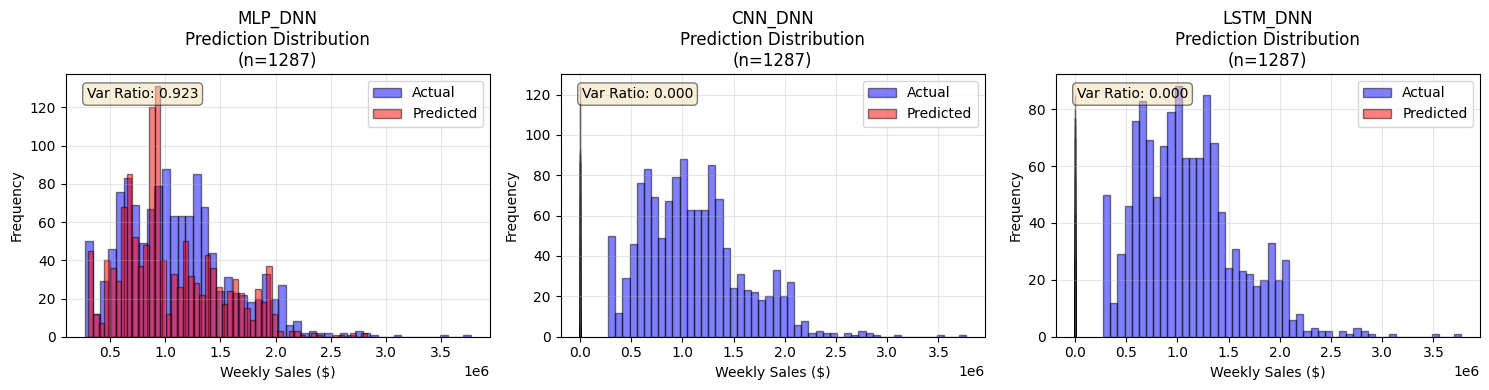

Saved ./Figure_Prediction_Distributions.png


In [78]:
# Diagnostic analysis: Prediction distribution comparison
print('='*80)
print('PREDICTION DISTRIBUTION ANALYSIS')
print('='*80)
print('This analysis reveals why CNN/LSTM failed: they output constant predictions.')
print()

# Analyze prediction variance for each model
print(f"Actual test sales statistics (MLP/CNN test set):")
print(f"  Mean: ${y_test.mean():,.0f}")
print(f"  Std:  ${y_test.std():,.0f}")
print(f"  Range: ${y_test.min():,.0f} to ${y_test.max():,.0f}")
print(f"  Samples: {len(y_test)}")
print()

print(f"LSTM test set (different size due to windowing):")
print(f"  Mean: ${y_test_lstm.mean():,.0f}")
print(f"  Std:  ${y_test_lstm.std():,.0f}")
print(f"  Samples: {len(y_test_lstm)}")
print()

models_data = [
    ('MLP_DNN', y_test, y_test_mlp, y_test.std()),
    ('CNN_DNN', y_test, y_test_cnn, y_test.std()),
    ('LSTM_DNN', y_test_lstm, y_test_lstm_pred, y_test_lstm.std()),  # Use LSTM's own test set
]

for model_name, y_true, y_pred, y_true_std in models_data:
    pred_mean = y_pred.mean()
    pred_std = y_pred.std()
    pred_min = y_pred.min()
    pred_max = y_pred.max()
    pred_range = pred_max - pred_min
    
    print(f"{model_name} predictions:")
    print(f"  Mean: ${pred_mean:,.0f}")
    print(f"  Std:  ${pred_std:,.0f}")
    print(f"  Range: ${pred_min:,.0f} to ${pred_max:,.0f}")
    print(f"  Samples: {len(y_pred)}")
    print(f"  Variance ratio (pred/actual): {(pred_std/y_true_std):.4f}")
    
    if pred_std < 1000:  # Very low variance indicates constant predictions
        print(f"  ⚠️  WARNING: Near-constant predictions (std < $1,000)!")
        print(f"  → Model outputs ≈${pred_mean:,.0f} for all samples")
        print(f"  → This is approximately the training set mean")
    print()

print('-'*80)
print('INTERPRETATION:')
print('• MLP: High variance (0.8-1.0 ratio) = learning actual patterns')
print('• CNN/LSTM: Near-zero variance = collapsing to mean prediction')
print('• CNN/LSTM never learned—they output constant values from initialization')
print('='*80)

# Visualize prediction distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, y_true, y_pred, _) in enumerate(models_data):
    ax = axes[idx]
    
    # Histogram of predictions vs actual
    ax.hist(y_true, bins=50, alpha=0.5, label='Actual', color='blue', edgecolor='black')
    ax.hist(y_pred, bins=50, alpha=0.5, label='Predicted', color='red', edgecolor='black')
    
    ax.set_xlabel('Weekly Sales ($)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{model_name}\nPrediction Distribution\n(n={len(y_pred)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add text annotation for variance
    pred_std = y_pred.std()
    true_std = y_true.std()
    variance_ratio = pred_std / true_std
    ax.text(0.05, 0.95, f'Var Ratio: {variance_ratio:.3f}', 
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
path = os.path.join(OUT_DIR, 'Figure_Prediction_Distributions.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {path}')


In [79]:
# Reproducibility & DNN utility: seeds, versions, and a shared model builder (regression)
import os, sys, random, json
os.environ['PYTHONHASHSEED'] = '42'
import numpy as np
import pandas as pd
import sklearn
np.random.seed(42)
random.seed(42)

try:
    import tensorflow as tf
    tf.random.set_seed(42)
    tf_version = tf.__version__
except Exception:
    tf = None
    tf_version = None

print('Environment versions:')
print('  python:', sys.version.split()[0])
print('  numpy :', np.__version__)
print('  pandas:', pd.__version__)
print('  sklearn:', sklearn.__version__)
print('  tensorflow:', tf_version)

# Shared regression model builder to harmonize with classification notebook (use kind='mlp' or 'cnn')
def build_model_regression(kind, input_dim, dropout=0.15, batchnorm=True, lr=1e-3, weight_decay=0.0):
    from tensorflow.keras import layers, models, optimizers, regularizers
    inp = layers.Input(shape=(input_dim,))
    x = inp
    if kind == 'mlp':
        x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
        if batchnorm: x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
        if batchnorm: x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
    elif kind == 'cnn':
        x_c = layers.Reshape((input_dim, 1))(x)
        x_c = layers.Conv1D(64, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x_c)
        if batchnorm: x_c = layers.BatchNormalization()(x_c)
        x_c = layers.Conv1D(64, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x_c)
        if batchnorm: x_c = layers.BatchNormalization()(x_c)
        x = layers.Flatten()(x_c)
        x = layers.Dense(128, activation='relu')(x)
    else:
        raise ValueError('Unknown kind')
    out = layers.Dense(1, activation='linear')(x)
    model = models.Model(inputs=inp, outputs=out)
    opt = optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

print('Inserted reproducibility and model builder utilities.')

Environment versions:
  python: 3.11.14
  numpy : 2.3.4
  pandas: 2.3.3
  sklearn: 1.7.2
  tensorflow: 2.20.0
Inserted reproducibility and model builder utilities.
